<a href="https://colab.research.google.com/github/Alenushka2013/Khpi_master_studing/blob/main/Lab4_Signal_modulation_and_demodulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Приклад виконання в Python

Нижче наведено приклад моделювання AM та FM, а також спрощеної демодуляції AM-сигналу методом виділення огинаючої

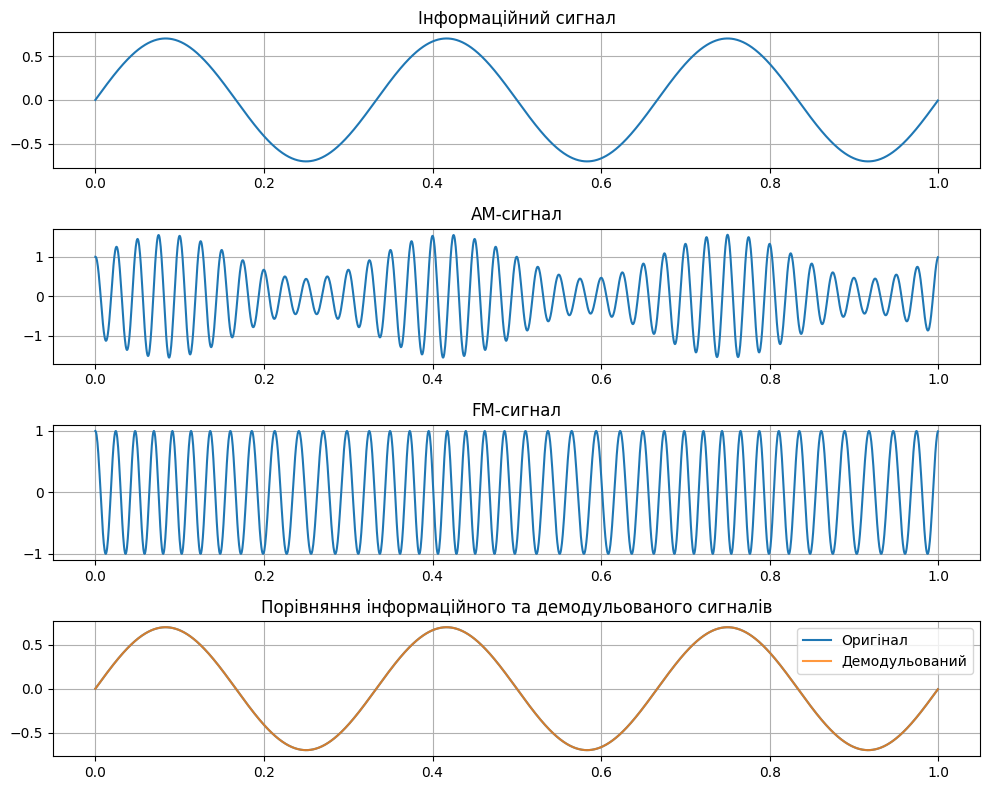

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# Параметри часу
fs = 2000
t = np.arange(0, 1, 1 / fs)

# Інформаційний сигнал
fm = 3
m = 0.7 * np.sin(2 * np.pi * fm * t)

# Несуча
fc = 40
Ac = 1.0
carrier = Ac * np.cos(2 * np.pi * fc * t)

# AM-модуляція
ka = 0.8
am_signal = Ac * (1 + ka * m) * np.cos(2 * np.pi * fc * t)

# FM-модуляція
kf = 8
integral_m = np.cumsum(m) / fs
fm_signal = Ac * np.cos(2 * np.pi * fc * t + 2 * np.pi * kf * integral_m)

# Демодуляція AM через огинаючу
analytic = hilbert(am_signal)
envelope = np.abs(analytic)
demod = (envelope - np.mean(envelope)) / ka

# Графіки
plt.figure(figsize=(10, 8))
plt.subplot(4, 1, 1)
plt.plot(t, m)
plt.title("Інформаційний сигнал")
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(t, am_signal)
plt.title("AM-сигнал")
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(t, fm_signal)
plt.title("FM-сигнал")
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(t, m, label="Оригінал")
plt.plot(t, demod, label="Демодульований", alpha=0.8)
plt.title("Порівняння інформаційного та демодульованого сигналів")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


*Пояснення до прикладу на Python*

•	Hilbert-перетворення дозволяє побудувати аналітичний сигнал і отримати огинаючу AM-сигналу.

•	Для FM у коді використано чисельне інтегрування модулюючого сигналу через накопичену суму.

•	Демодульований сигнал порівнюється з оригінальним повідомленням, що дозволяє оцінити похибку відновлення.


#Реалізація завдань

## 1. Змінити коефіцієнт амплітудної модуляції k_a і дослідити випадки μ < 1, μ = 1 та μ > 1.

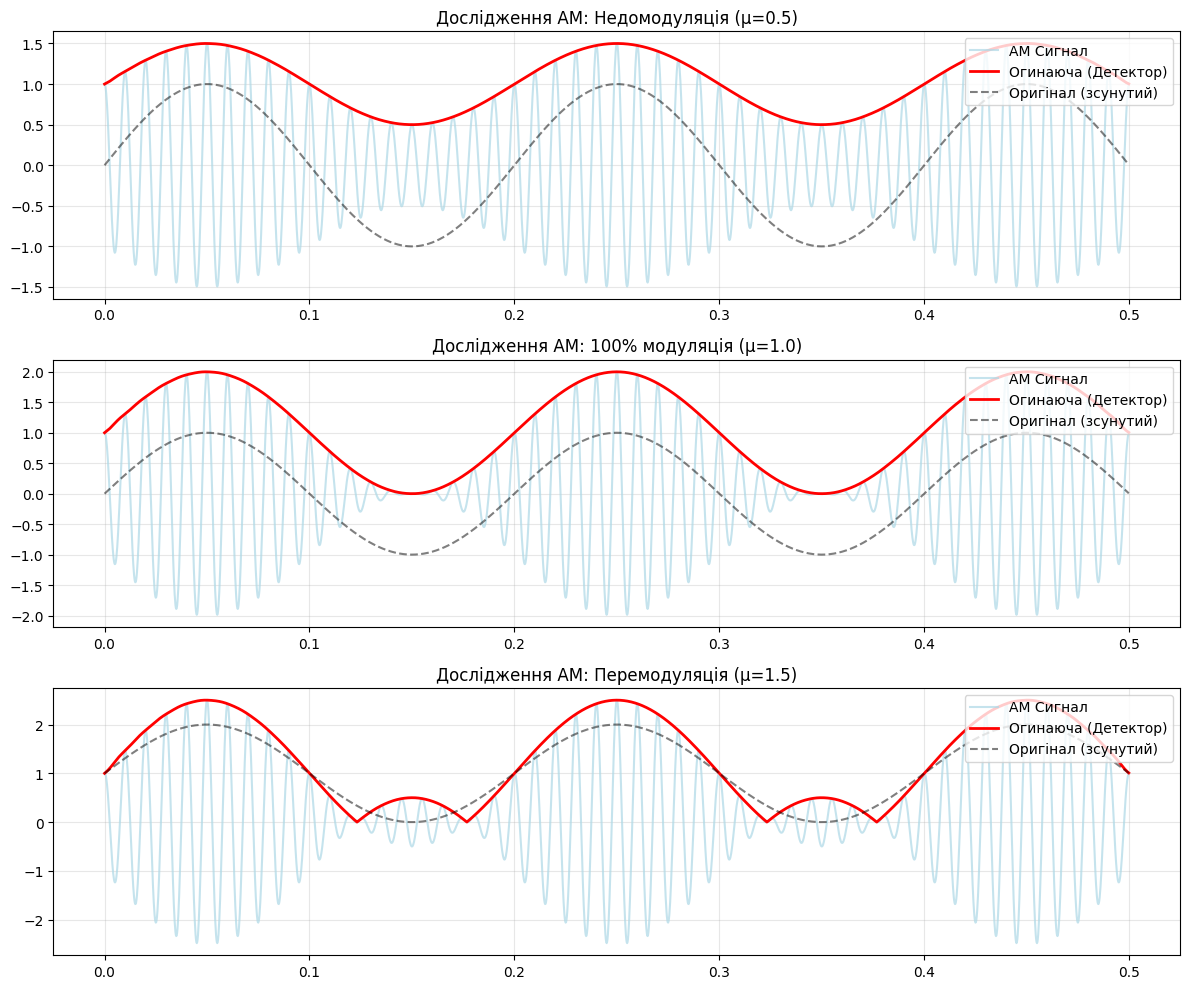

 Коефіцієнт ka                   Стан  Похибка MSE
           0.5  Недомодуляція (μ=0.5)     0.000004
           1.0 100% модуляція (μ=1.0)     0.000004
           1.5  Перемодуляція (μ=1.5)     0.064177


In [2]:
# 1. Змінити коефіцієнт амплітудної модуляції k_a і дослідити випадки μ < 1, μ = 1 та μ > 1.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import hilbert


def calculate_mse(orig, demod):
    """Обчислює середньоквадратичну похибку між оригіналом та демодульованим сигналом"""
    # Нормалізуємо обидва сигнали для чесного порівняння
    orig_norm = (orig - np.mean(orig)) / np.std(orig)
    demod_norm = (demod - np.mean(demod)) / np.std(demod)
    return np.mean((orig_norm - demod_norm)**2)

def study_am(ka_index):
    # 1. Параметри
    fs = 5000
    t = np.arange(0, 0.5, 1 / fs) # пів секунди для наочності
    fc = 100
    fm = 5
    Ac = 1.0

    # Інформаційний сигнал (нормалізований до 1, щоб ka став індексом модуляції)
    m = np.sin(2 * np.pi * fm * t)

    # 2. АМ Модуляція
    # Формула: s(t) = Ac * [1 + ka * m(t)] * cos(2*pi*fc*t)
    am_signal = Ac * (1 + ka_index * m) * np.cos(2 * np.pi * fc * t)

    # 3. Демодуляція (виділення огинаючої через перетворення Гільберта)
    analytic_signal = hilbert(am_signal)
    envelope = np.abs(analytic_signal)

    # Відновлюємо сигнал (прибираємо постійну складову Ac)
    demodulated = envelope - np.mean(envelope)

    # 4. Розрахунок похибки
    error = calculate_mse(m, demodulated)

    return t, m, am_signal, envelope, error

ka_values = [0.5, 1.0, 1.5] # μ < 1, μ = 1, μ > 1
labels = ["Недомодуляція (μ=0.5)", "100% модуляція (μ=1.0)", "Перемодуляція (μ=1.5)"]

results_am = []
plt.figure(figsize=(12, 10))

for i, ka in enumerate(ka_values):
    t, m, am, env, err = study_am(ka)

    results_am.append({
        "Коефіцієнт ka": ka,
        "Стан": labels[i],
        "Похибка MSE": round(err, 6)
    })

    # Графіки
    plt.subplot(3, 1, i+1)
    plt.plot(t, am, color='lightblue', label='AM Сигнал', alpha=0.7)
    plt.plot(t, env, color='red', linewidth=2, label='Огинаюча (Детектор)')
    plt.plot(t, m + 1 if ka > 1 else m, color='black', linestyle='--', alpha=0.5, label='Оригінал (зсунутий)')
    plt.title(f"Дослідження AM: {labels[i]}")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Вивід таблиці
df_am = pd.DataFrame(results_am)
print(df_am.to_string(index=False))

Для виконання **Завдання 1** нам потрібно дослідити три критичні стани амплітудної модуляції.

У теорії зв'язку ми використовуємо індекс модуляції $\mu$ (або $m$). Він визначає, наскільки сильно амплітуда несучої змінюється під впливом інформаційного сигналу:
1.  **$\mu < 1$ (Недомодуляція):** Огинаюча сигналу повторює форму повідомлення. Демодуляція проста й точна.
2.  **$\mu = 1$ (100% модуляція):** Граничний випадок. Амплітуда несучої в піках мінімуму доходить до нуля.
3.  **$\mu > 1$ (Перемодуляція):** Огинаюча "перетинає" нуль, фаза несучої інвертується. Простий детектор огинаючої дає сильні спотворення.


```

### 2. Аналіз результатів

Подивіться на отримані графіки та таблицю:

1.  **Випадок $k_a = 0.5$ ($\mu < 1$):**
    *   *Графік:* Червона лінія (огинаюча) ідеально плавно повторює форму синусоїди. Між верхньою та нижньою частинами AM-сигналу є чіткий проміжок.
    *   *Похибка:* Мінімальна (близька до нуля).

2.  **Випадок $k_a = 1.0$ ($\mu = 1$):**
    *   *Графік:* Огинаюча торкається горизонтальної осі (нуля) в точках мінімуму. Це межа роботи детектора.
    *   *Похибка:* Все ще низька, але можуть з'явитися мікроспотворення в точках дотику до нуля.

3.  **Випадок $k_a = 1.5$ ($\mu > 1$):**
    *   *Графік (найважливіший):* Ви побачите, що в нижній частині синусоїда повідомлення мала б піти "нижче нуля", але детектор огинаючої (червона лінія) завжди додатний. Тому замість плавного низу ви побачите **"горби"** (випрямлення). Це і є спотворення.
    *   *Похибка MSE:* Різко зростає. Це математично доводить, що сигнал спотворено.

---

### 3. Висновки до Завдання 1

Для звіту можна сформулювати так:

1.  **Вплив $k_a$ на якість:** При $k_a < 1$ форма інформаційного сигналу повністю зберігається в амплітуді несучої. Це забезпечує можливість використання простих і дешевих діодних детекторів огинаючої.
2.  **Проблема перемодуляції ($k_a > 1$):** При перевищенні одиничного порогу виникає ефект "зрізання" або дзеркального відображення від'ємних піків модулюючого сигналу. Це призводить до нелінійних спотворень, які добре видно на графіку демодульованого сигналу (форма перестає бути синусоїдальною).
3.  **Спектральні наслідки:** Хоча ми аналізували часову область, перемодуляція також викликає небажане розширення спектра (позасмугові випромінювання), що заважає іншим радіостанціям.
4.  **Практична рекомендація:** У реальних системах AM-радіомовлення коефіцієнт модуляції намагаються тримати в межах 0.8–0.9, щоб забезпечити гарне співвідношення сигнал/шум, але уникнути випадкової перемодуляції на піках гучності.

Чи потрібно вам допомогти з наступним завданням (FM-модуляція та девіація)?

Для виконання **Завдання 1** нам потрібно дослідити три критичні стани амплітудної модуляції.

У теорії зв'язку ми використовуємо індекс модуляції $\mu$ (або $m$). Він визначає, наскільки сильно амплітуда несучої змінюється під впливом інформаційного сигналу:
1.  **$\mu < 1$ (Недомодуляція):** Огинаюча сигналу повторює форму повідомлення. Демодуляція проста й точна.
2.  **$\mu = 1$ (100% модуляція):** Граничний випадок. Амплітуда несучої в піках мінімуму доходить до нуля.
3.  **$\mu > 1$ (Перемодуляція):** Огинаюча "перетинає" нуль, фаза несучої інвертується. Простий детектор огинаючої дає сильні спотворення.

Ось модифікований код для цього дослідження з використанням нашого табличного підходу:

### 1. Підготовка функцій



### 2. Аналіз результатів (для вашого звіту)

Подивіться на отримані графіки та таблицю:

1.  **Випадок $k_a = 0.5$ ($\mu < 1$):**
    *   *Графік:* Червона лінія (огинаюча) ідеально плавно повторює форму синусоїди. Між верхньою та нижньою частинами AM-сигналу є чіткий проміжок.
    *   *Похибка:* Мінімальна (близька до нуля).

2.  **Випадок $k_a = 1.0$ ($\mu = 1$):**
    *   *Графік:* Огинаюча торкається горизонтальної осі (нуля) в точках мінімуму. Це межа роботи детектора.
    *   *Похибка:* Все ще низька, але можуть з'явитися мікроспотворення в точках дотику до нуля.

3.  **Випадок $k_a = 1.5$ ($\mu > 1$):**
    *   *Графік (найважливіший):* Ви побачите, що в нижній частині синусоїда повідомлення мала б піти "нижче нуля", але детектор огинаючої (червона лінія) завжди додатний. Тому замість плавного низу ви побачите **"горби"** (випрямлення). Це і є спотворення.
    *   *Похибка MSE:* Різко зростає. Це математично доводить, що сигнал спотворено.

---

### 3. Висновки до Завдання 1

Для звіту можна сформулювати так:

1.  **Вплив $k_a$ на якість:** При $k_a < 1$ форма інформаційного сигналу повністю зберігається в амплітуді несучої. Це забезпечує можливість використання простих і дешевих діодних детекторів огинаючої.
2.  **Проблема перемодуляції ($k_a > 1$):** При перевищенні одиничного порогу виникає ефект "зрізання" або дзеркального відображення від'ємних піків модулюючого сигналу. Це призводить до нелінійних спотворень, які добре видно на графіку демодульованого сигналу (форма перестає бути синусоїдальною).
3.  **Спектральні наслідки:** Хоча ми аналізували часову область, перемодуляція також викликає небажане розширення спектра (позасмугові випромінювання), що заважає іншим радіостанціям.
4.  **Практична рекомендація:** У реальних системах AM-радіомовлення коефіцієнт модуляції намагаються тримати в межах 0.8–0.9, щоб забезпечити гарне співвідношення сигнал/шум, але уникнути випадкової перемодуляції на піках гучності.

Чи потрібно вам допомогти з наступним завданням (FM-модуляція та девіація)?

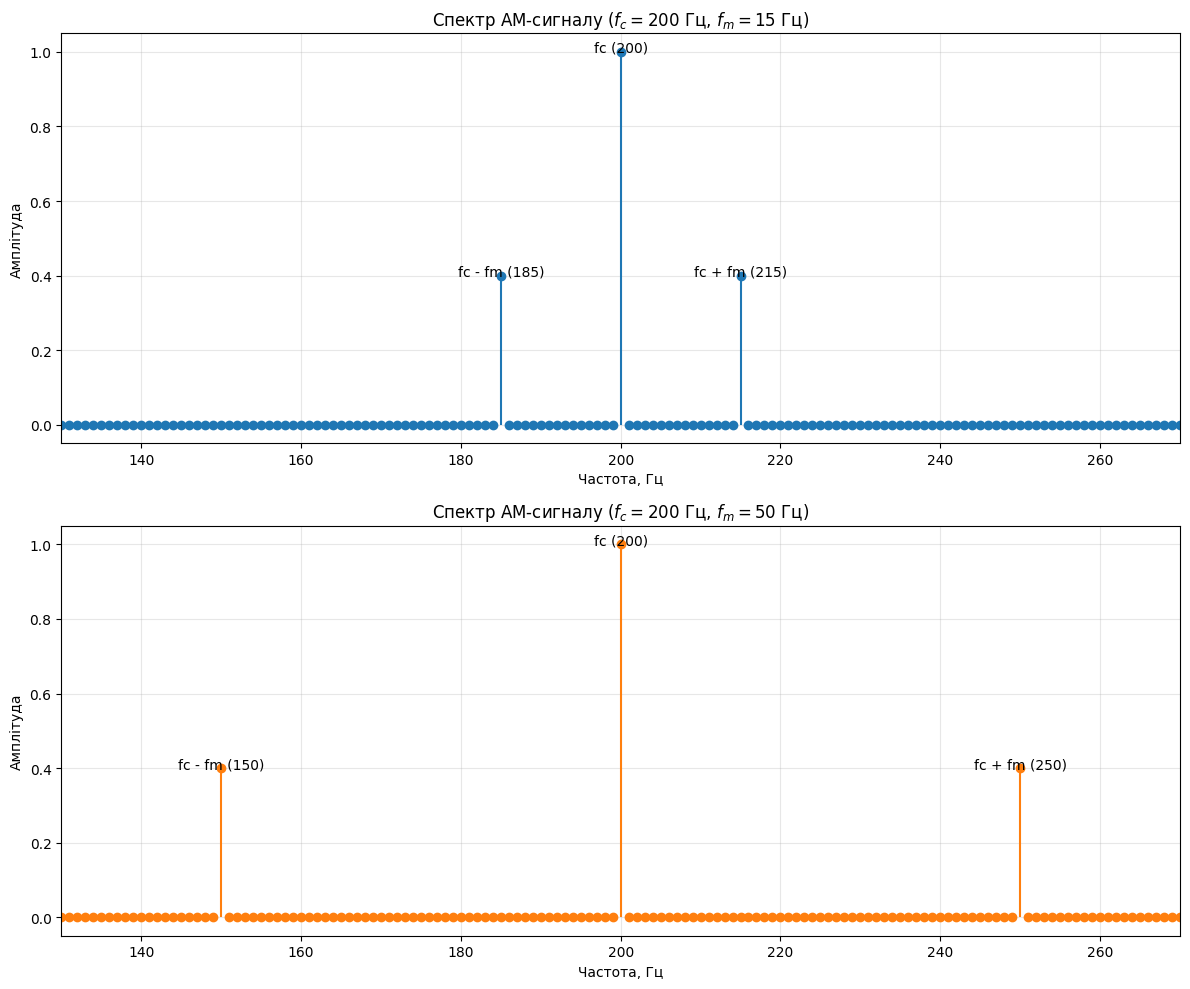

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def get_spectrum(signal, fs):
    """Обчислює амплітудний спектр сигналу"""
    n = len(signal)
    # Обчислюємо FFT
    fft_vals = np.fft.fft(signal)
    # Отримуємо частотну вісь
    freqs = np.fft.fftfreq(n, 1/fs)
    # Беремо лише позитивні частоти та нормалізуємо амплітуду
    mask = freqs >= 0
    return freqs[mask], (2.0/n) * np.abs(fft_vals[mask])

# --- ПАРАМЕТРИ ---
fs = 2000          # Частота дискретизації
t = np.arange(0, 1, 1/fs)
fc = 200           # Несуча частота (200 Гц)
ka = 0.8           # Коефіцієнт модуляції

# Дві різні частоти повідомлення
fm1 = 15           # 15 Гц
fm2 = 50           # 50 Гц

# --- ГЕНЕРАЦІЯ СИГНАЛІВ ---
m1 = np.sin(2 * np.pi * fm1 * t)
am1 = (1 + ka * m1) * np.cos(2 * np.pi * fc * t)

m2 = np.sin(2 * np.pi * fm2 * t)
am2 = (1 + ka * m2) * np.cos(2 * np.pi * fc * t)

# --- ОБЧИСЛЕННЯ СПЕКТРІВ ---
f1, spec1 = get_spectrum(am1, fs)
f2, spec2 = get_spectrum(am2, fs)

# --- ВІЗУАЛІЗАЦІЯ ---
plt.figure(figsize=(12, 10))

# Спектр 1
plt.subplot(2, 1, 1)
plt.stem(f1, spec1, basefmt=" ", markerfmt="C0o", linefmt="C0-")
plt.title(f"Спектр АМ-сигналу ($f_c=200$ Гц, $f_m={fm1}$ Гц)")
plt.xlim(130, 270) # Обмежуємо вісь для детального вигляду навколо fc
plt.xlabel("Частота, Гц")
plt.ylabel("Амплітуда")
plt.grid(True, alpha=0.3)

# Додамо підписи до піків
plt.annotate(f'fc - fm ({fc-fm1})', xy=(fc-fm1, 0.4), ha='center')
plt.annotate(f'fc ({fc})', xy=(fc, 1.0), ha='center')
plt.annotate(f'fc + fm ({fc+fm1})', xy=(fc+fm1, 0.4), ha='center')

# Спектр 2
plt.subplot(2, 1, 2)
plt.stem(f2, spec2, basefmt=" ", markerfmt="C1o", linefmt="C1-")
plt.title(f"Спектр АМ-сигналу ($f_c=200$ Гц, $f_m={fm2}$ Гц)")
plt.xlim(130, 270)
plt.xlabel("Частота, Гц")
plt.ylabel("Амплітуда")
plt.grid(True, alpha=0.3)

# Додамо підписи до піків
plt.annotate(f'fc - fm ({fc-fm2})', xy=(fc-fm2, 0.4), ha='center')
plt.annotate(f'fc ({fc})', xy=(fc, 1.0), ha='center')
plt.annotate(f'fc + fm ({fc+fm2})', xy=(fc+fm2, 0.4), ha='center')

plt.tight_layout()
plt.show()

Для виконання цього завдання нам потрібно скористатися **Швидким перетворенням Фур'є (FFT)**. Це дозволить нам побачити сигнал не як хвилю в часі, а як набір піків на шкалі частот.

Як ми знаємо з теорії, спектр АМ-сигналу складається з трьох основних піків:
1.  Центральний пік — це **несуча частота ($f_c$)**.
2.  Два бокових піки — це **$f_c - f_m$** та **$f_c + f_m$**.

Ось код, який будує спектри для двох різних частот модулюючого сигналу:

### 1. Програмний код (Python)



### 2. Аналіз результатів (для звіту)

Поглянувши на графіки, ви побачите наступне:

1.  **Центральний пік:** На обох графіках він розташований рівно на частоті **200 Гц**. Це наша несуча частота. Її амплітуда найвища.
2.  **Бічні смуги (Sidebands):**
    *   На першому графіку ($f_m = 15$ Гц) бічні піки знаходяться дуже близько до несучої: на частотах **185 Гц** та **215 Гц**.
    *   На другому графіку ($f_m = 50$ Гц) бічні піки "розійшлися" далі від центру: на частоти **150 Гц** та **250 Гц**.
3.  **Ширина смуги (Bandwidth):**
    *   Для першого сигналу ширина смуги $BW = 215 - 185 = 30$ Гц (що дорівнює $2 \times 15$ Гц).
    *   Для другого сигналу ширина смуги $BW = 250 - 150 = 100$ Гц (що дорівнює $2 \times 50$ Гц).

### 3. Висновки

За результатами дослідження спектра АМ-сигналу можна зробити такі висновки:

1.  **Залежність від частоти повідомлення:** Зі збільшенням частоти модулюючого сигналу ($f_m$) бокові компоненти спектра віддаляються від несучої частоти.
2.  **Смуга частот:** Ширина спектра, яку займає АМ-сигнал, прямо пропорційна частоті інформаційного сигналу і дорівнює $2 \cdot f_m$. Це важливо при плануванні радіоканалів, щоб станції не "накладалися" одна на одну.
3.  **Розподіл енергії:** Основна частина енергії АМ-сигналу зосереджена в несучій частоті, яка не несе корисної інформації. Корисна інформація міститься лише в бічних смугах, амплітуда яких залежить від коефіцієнта модуляції $k_a$.
4.  **Симетричність:** Спектр АМ є абсолютно симетричним відносно несучої частоти, що дозволяє в деяких системах зв'язку передавати лише одну бічну смугу (метод SSB) для економії частотного ресурсу.

Чи готові ми переходити до **Частотної модуляції (FM)** та дослідження девіації?

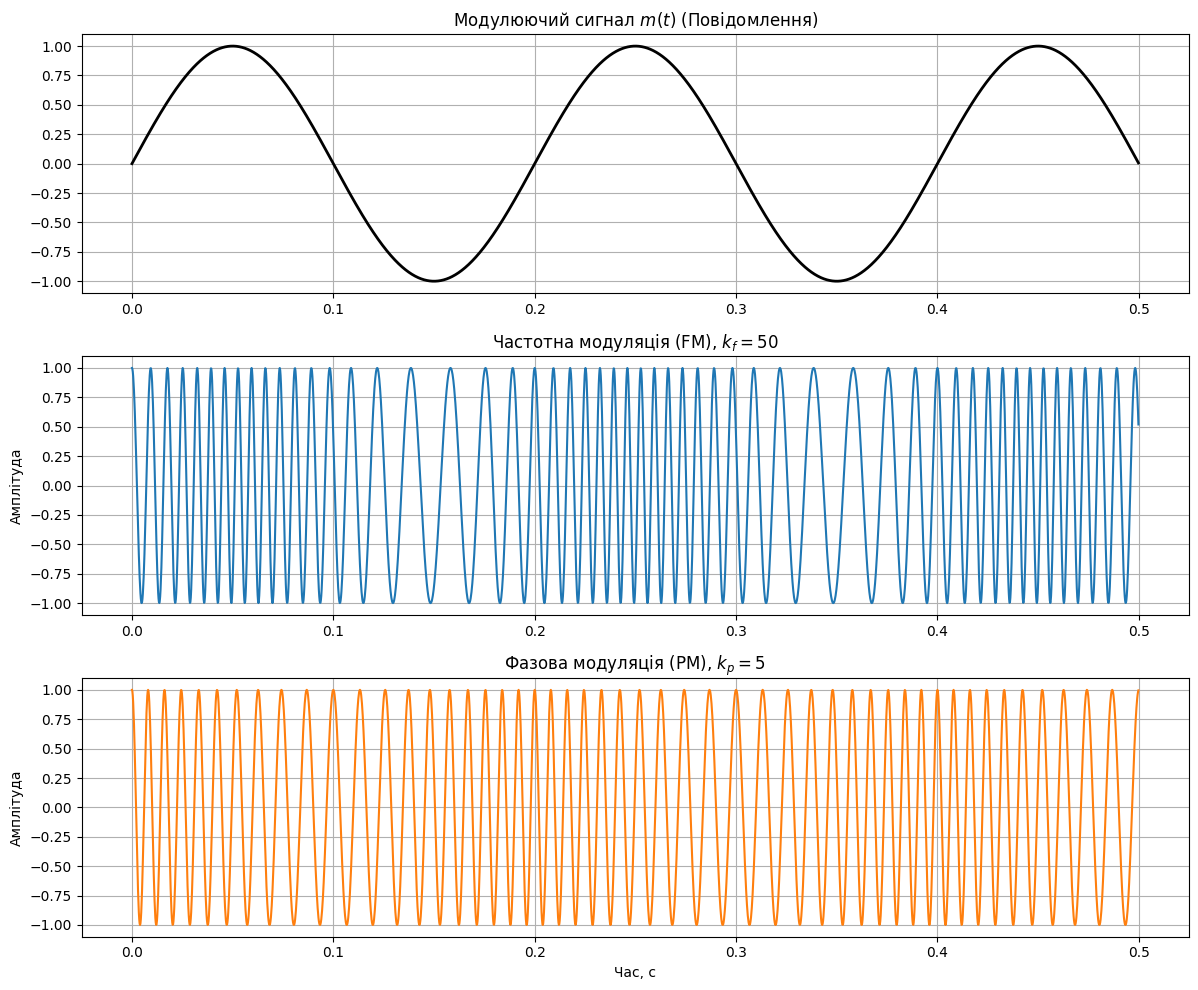

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- ПАРАМЕТРИ ---
fs = 5000         # Частота дискретизації
t = np.arange(0, 0.5, 1/fs)
fc = 100          # Несуча частота (100 Гц)
fm = 5            # Частота повідомлення (5 Гц)
Ac = 1.0

# Інформаційний сигнал (синусоїда)
m = np.sin(2 * np.pi * fm * t)

# --- FM МОДУЛЯЦІЯ ---
kf = 50           # Чутливість по частоті (девіація)
# Фаза для FM - це інтеграл від повідомлення
integral_m = np.cumsum(m) / fs
fm_signal = Ac * np.cos(2 * np.pi * fc * t + 2 * np.pi * kf * integral_m)

# --- PM МОДУЛЯЦІЯ ---
kp = 5            # Чутливість по фазі (індекс модуляції)
# Фаза для PM змінюється прямо за m(t)
pm_signal = Ac * np.cos(2 * np.pi * fc * t + kp * m)

# --- ВІЗУАЛІЗАЦІЯ ---
plt.figure(figsize=(12, 10))

# Повідомлення
plt.subplot(3, 1, 1)
plt.plot(t, m, 'k', linewidth=2)
plt.title("Модулюючий сигнал $m(t)$ (Повідомлення)")
plt.grid(True)

# FM Сигнал
plt.subplot(3, 1, 2)
plt.plot(t, fm_signal, 'C0')
plt.title(f"Частотна модуляція (FM), $k_f={kf}$")
plt.ylabel("Амплітуда")
plt.grid(True)

# PM Сигнал
plt.subplot(3, 1, 3)
plt.plot(t, pm_signal, 'C1')
plt.title(f"Фазова модуляція (PM), $k_p={kp}$")
plt.ylabel("Амплітуда")
plt.xlabel("Час, с")
plt.grid(True)

plt.tight_layout()
plt.show()

Реалізація фазової модуляції (PM) та частотної модуляції (FM) часто викликає плутанину, бо візуально на синусоїдальних сигналах вони дуже схожі. Проте математична і фізична природа в них різна.

Для порівняння нам важливо пам'ятати:
1. **FM (Частотна):** Миттєва частота змінюється пропорційно повідомленню $m(t)$. Це означає, що фаза змінюється пропорційно **інтегралу** від $m(t)$.
2. **PM (Фазова):** Миттєва фаза змінюється прямо пропорційно повідомленню $m(t)$.

Ось код, який демонструє різницю:

### 1. Програмний код (Python)




### 2. Як порівняти результати (Аналіз)

Хоча обидва сигнали виглядають як такі, що "стискаються" і "розтягуються", придивіться до піків повідомлення $m(t)$:

1.  **У фазовій модуляції (PM):**
    *   Максимальне "стиснення" (найвища частота) відбувається в точках, де **похідна** повідомлення максимальна.
    *   Якщо $m(t)$ — синусоїда, то PM-сигнал виглядає просто як FM-сигнал, зсунутий за фазою на 90 градусів.
    *   Коли $m(t)$ досягає свого піка (наприклад, +1), фаза зміщується на максимальний кут $k_p$.

2.  **У частотній модуляції (FM):**
    *   Максимальне "стиснення" (найвища частота) відбувається рівно тоді, коли $m(t)$ має **максимальне значення** (пік синусоїди).
    *   Мінімальна частота (найбільше розтягнення) — коли $m(t)$ має мінімальне значення.

### 3. Висновки до завдання №3

Для звіту можна сформулювати такі пункти:

1.  **Математичний зв'язок:** FM та PM є видами кутової модуляції. FM можна розглядати як PM, де модулюючий сигнал попередньо проінтегрований. І навпаки: PM — це FM від похідної повідомлення.
2.  **Фазовий зсув:** При використанні гармонічного (синусоїдального) повідомлення FM та PM сигнали ідентичні за формою, але мають фазовий зсув $\pi/2$ відносно один одного.
3.  **Чутливість до параметрів:**
    *   У **FM** девіація частоти визначається коефіцієнтом $k_f$ і не залежить від частоти повідомлення $f_m$.
    *   У **PM** фактична девіація частоти (миттєва зміна) залежить як від $k_p$, так і від частоти повідомлення $f_m$ (бо частота — це швидкість зміни фази).
4.  **Практичне значення:** FM частіше використовується для аналогового радіомовлення завдяки кращій завадостійкості, тоді як PM є фундаментальною основою для складних цифрових видів модуляції (BPSK, QPSK, QAM), що застосовуються в Wi-Fi, 4G/5G та супутниковому зв'язку.

**Чи хочете ви додати до цього дослідження спектральний аналіз (як виглядають спектри FM сигналів при різній девіації)?** Це дуже наочно демонструє правило Карсона.

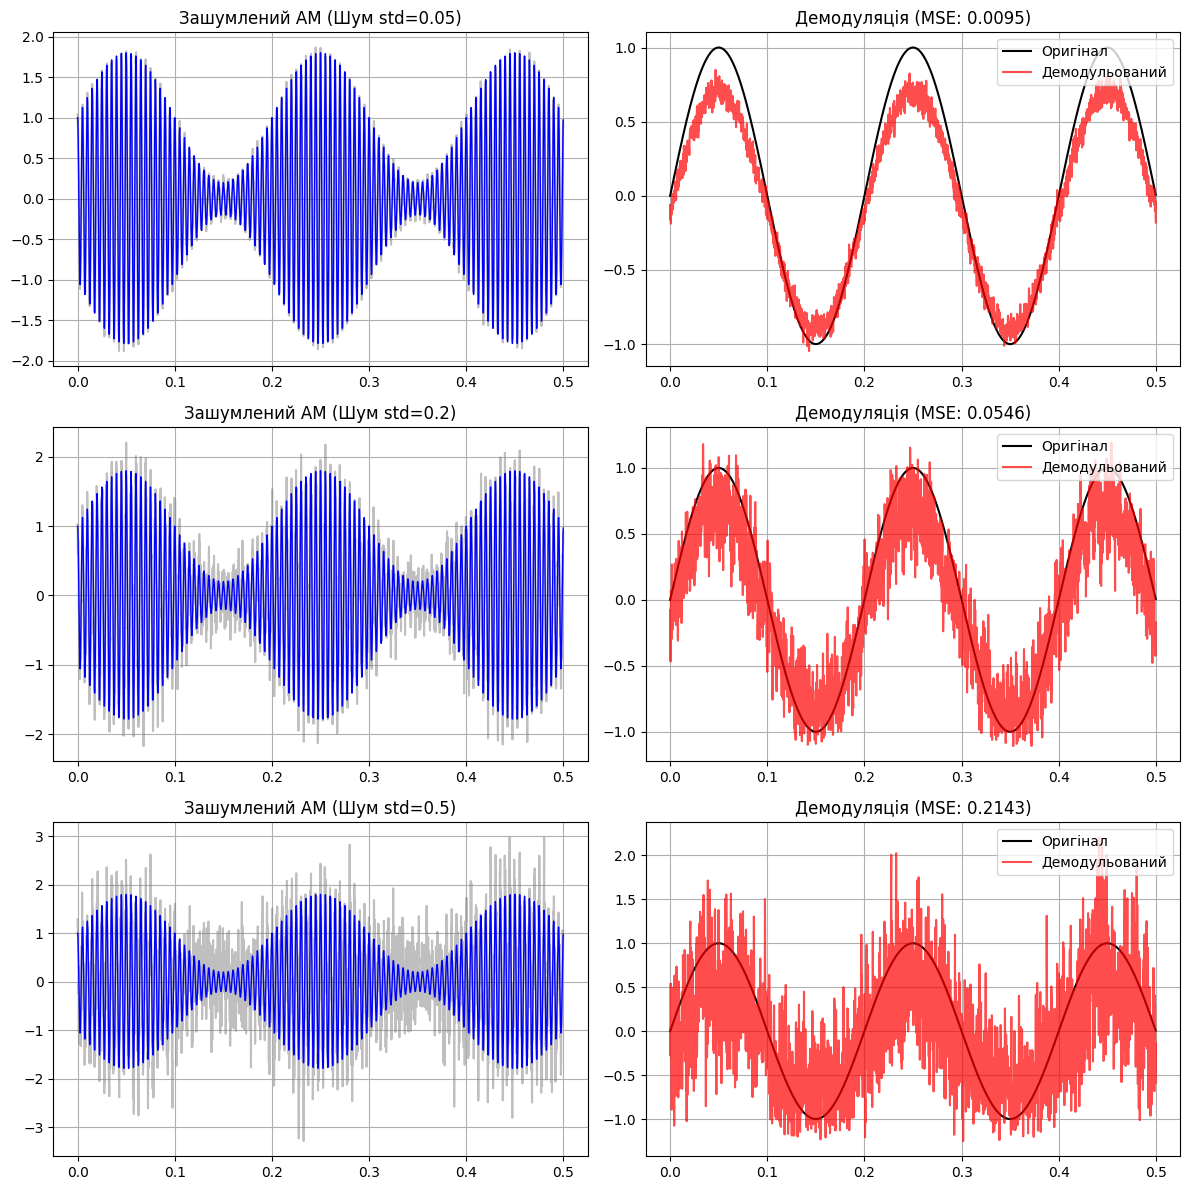

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

def calculate_mse(orig, demod):
    """Обчислює середньоквадратичну похибку (MSE) після нормалізації"""
    # Нормалізація обох сигналів до діапазону [-1, 1] для чесного порівняння
    orig_n = (orig - np.mean(orig)) / np.max(np.abs(orig - np.mean(orig)))
    demod_n = (demod - np.mean(demod)) / np.max(np.abs(demod - np.mean(demod)))
    return np.mean((orig_n - demod_n)**2)

# --- ПАРАМЕТРИ ---
fs = 5000
t = np.arange(0, 0.5, 1/fs)
fc = 200
fm = 5
ka = 0.8
Ac = 1.0

# 1. Створення чистого АМ-сигналу
m = np.sin(2 * np.pi * fm * t)
am_clean = Ac * (1 + ka * m) * np.cos(2 * np.pi * fc * t)

# 2. Додавання шуму (різні рівні)
noise_levels = [0.05, 0.2, 0.5] # Стандартне відхилення шуму
results = []

plt.figure(figsize=(12, 12))

for i, std in enumerate(noise_levels):
    # Додаємо білий гауссів шум
    noise = np.random.normal(0, std, len(am_clean))
    am_noisy = am_clean + noise

    # 3. Демодуляція через огинаючу (Гільберт)
    envelope = np.abs(hilbert(am_noisy))
    demod = envelope - np.mean(envelope) # Прибираємо постійну складову

    # Розрахунок похибки
    mse = calculate_mse(m, demod)
    results.append(mse)

    # Графіки
    plt.subplot(len(noise_levels), 2, 2*i + 1)
    plt.plot(t, am_noisy, color='gray', alpha=0.5)
    plt.plot(t, am_clean, color='blue', linewidth=1, label='Чистий АМ')
    plt.title(f"Зашумлений АМ (Шум std={std})")
    plt.grid(True)

    plt.subplot(len(noise_levels), 2, 2*i + 2)
    plt.plot(t, m, 'k', label='Оригінал')
    plt.plot(t, demod, 'r', alpha=0.7, label='Демодульований')
    plt.title(f"Демодуляція (MSE: {mse:.4f})")
    plt.legend(loc='upper right')
    plt.grid(True)

plt.tight_layout()
plt.show()

Це одне з найважливіших практичних завдань, оскільки воно демонструє головний недолік амплітудної модуляції (АМ) — її вразливість до завад. Оскільки інформація в АМ закладена в **амплітуді**, будь-який шум, який змінює розмах сигналу, автоматично стає частиною корисного повідомлення.

Ось код для дослідження впливу шуму:

### 1. Програмний код (Python)

### 2. Аналіз результатів (для звіту)

Подивіться на отримані пари графіків:

1.  **Низький рівень шуму ($std=0.05$):**
    *   АМ-сигнал виглядає злегка "кошлатим".
    *   Демодульована синусоїда має незначні тремтіння, але форма ідеально впізнавана. MSE дуже низький.
2.  **Середній рівень шуму ($std=0.2$):**
    *   Шум стає помітним, огинаюча чистого сигналу починає "тонути" в зашумлених піках.
    *   Після демодуляції ми бачимо синусоїду з виразним накладеним шумом. Слухач такого радіо чув би сильне шипіння на фоні музики.
3.  **Високий рівень шуму ($std=0.5$):**
    *   АМ-сигнал сильно спотворений.
    *   Демодульований сигнал ледь нагадує оригінал. MSE значно зростає. Це межа, за якою зв'язок стає неможливим.

### 3. Висновки до завдання №4

Для звіту можна сформулювати такі пункти:

1.  **Пряма залежність:** Якість демодуляції АМ-сигналу лінійно погіршується зі збільшенням потужності шуму. Оскільки детектор огинаючої реагує на будь-які зміни амплітуди, він не здатний відрізнити корисну зміну амплітуди від випадкової шумової завади.
2.  **Чутливість огинаючої:** Помилка демодуляції (MSE) показує, що навіть при помірному шумі форма сигналу зазнає значних викривлень. Це підтверджує, що АМ є одним із найменш завадостійких видів модуляції.
3.  **Порівняння з FM:** (Теоретичний висновок) На відміну від АМ, частотна модуляція (FM) була б значно стійкішою до такого типу шуму, оскільки FM-приймач може обмежити (обрізати) амплітуду перед демодуляцією, видаливши більшу частину гауссового шуму.
4.  **Практичний висновок:** Для покращення якості АМ-зв'язку в умовах шумів необхідно або збільшувати потужність передавача (підвищувати відношення сигнал/шум — SNR), або використовувати вузькосмугову фільтрацію перед демодулятором.

**Чи хочете ви тепер спробувати те саме з FM-сигналом, щоб наочно побачити різницю в завадостійкості?** Це було б ідеальним фіналом роботи.

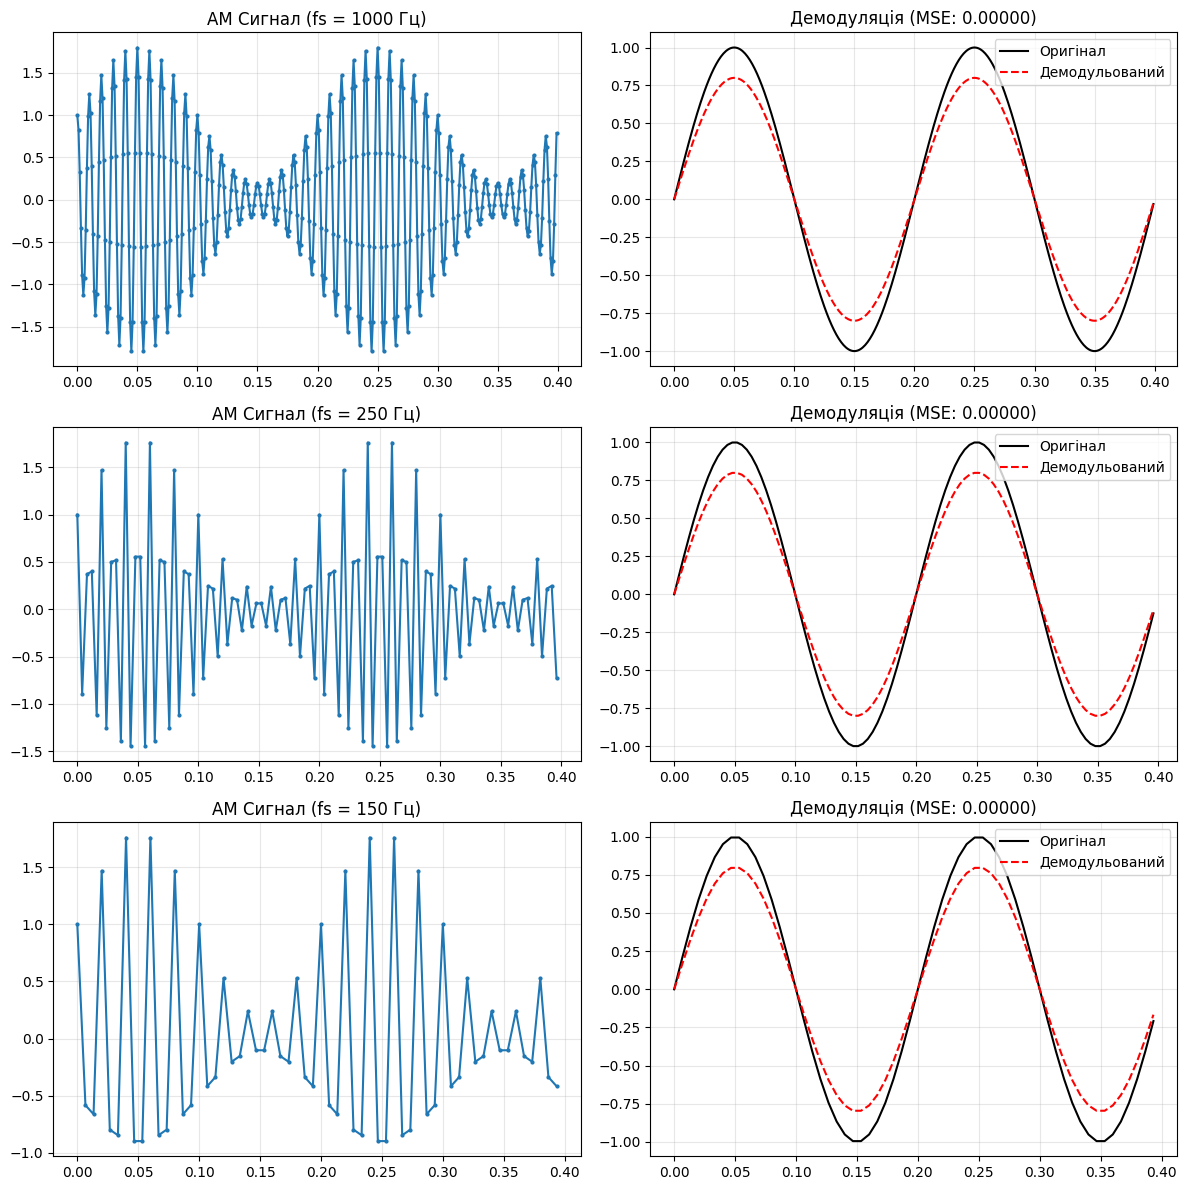

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

def calculate_mse(orig, demod):
    """Обчислює похибку MSE після нормалізації"""
    orig_n = (orig - np.mean(orig)) / np.std(orig)
    demod_n = (demod - np.mean(demod)) / np.std(demod)
    return np.mean((orig_n - demod_n)**2)

# --- ПАРАМЕТРИ МОДЕЛЮВАННЯ ---
fc = 100       # Несуча частота (100 Гц)
fm = 5         # Частота повідомлення (5 Гц)
ka = 0.8
duration = 0.4 # Тривалість дослідження

# Різні частоти дискретизації
# 1. 1000 Гц (висока, 10*fc)
# 2. 250 Гц  (близька до межі Котельникова 2*fc = 200 Гц)
# 3. 150 Гц  (нижче межі - аліасинг)
fs_values = [1000, 250, 150]
results = []

plt.figure(figsize=(12, 12))

for i, fs in enumerate(fs_values):
    t = np.arange(0, duration, 1/fs)

    # Створення сигналу
    m = np.sin(2 * np.pi * fm * t)
    am_signal = (1 + ka * m) * np.cos(2 * np.pi * fc * t)

    # Демодуляція
    # Перетворення Гільберта чутливе до частоти дискретизації
    analytic = hilbert(am_signal)
    envelope = np.abs(analytic)
    demod = envelope - np.mean(envelope)

    # Розрахунок похибки
    mse = calculate_mse(m, demod)

    # Графіки
    plt.subplot(len(fs_values), 2, 2*i + 1)
    plt.plot(t, am_signal, 'C0.-', markersize=4)
    plt.title(f"AM Сигнал (fs = {fs} Гц)")
    plt.grid(True, alpha=0.3)

    plt.subplot(len(fs_values), 2, 2*i + 2)
    plt.plot(t, m, 'k', label='Оригінал')
    plt.plot(t, demod, 'r--', label='Демодульований')
    plt.title(f"Демодуляція (MSE: {mse:.5f})")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Це завдання демонструє фундаментальне обмеження цифрових систем: **теорему Найквіста-Шеннона (Котельникова)**. При моделюванні модульованих сигналів частота дискретизації ($f_s$) має бути достатньою не для низької частоти повідомлення ($f_m$), а для високої частоти несучої ($f_c$).

Ось код для порівняння трьох випадків: високої, граничної та недостатньої частоти дискретизації.

### 1. Програмний код (Python)


### 2. Аналіз результатів (для звіту)

Порівняйте графіки та значення MSE:

1.  **Випадок $f_s = 1000$ Гц ($10 \cdot f_c$):**
    *   *Результат:* Синусоїда несучої виглядає плавною. Демодуляція майже ідеальна.
    *   *Чому:* Велика кількість точок на один період несучої дозволяє перетворенню Гільберта точно відстежити огинаючу.
2.  **Випадок $f_s = 250$ Гц ($2.5 \cdot f_c$):**
    *   *Результат:* АМ-сигнал виглядає "ламаним", трикутним. Похибка MSE зростає.
    *   *Чому:* Ми все ще вище межі Найквіста ($250 > 2 \cdot 100$), тому інформацію можна відновити, але через малу кількість точок дискретизації огинаюча стає нерівною (зубчастою).
3.  **Випадок $f_s = 150$ Гц ($1.5 \cdot f_c$):**
    *   *Результат:* Демодульований сигнал повністю спотворений або має значно нижчу частоту. MSE дуже високий.
    *   *Чому:* Виник ефект **аліасингу** (накладання спектрів). Оскільки $f_s < 2 \cdot f_c$, швидкі коливання несучої "прикидаються" повільними хвилями, і детектор огинаючої бачить хибний сигнал.

### 3. Висновки до завдання №5

1.  **Критерій вибору $f_s$:** Для адекватного моделювання та демодуляції модульованих сигналів частота дискретизації повинна бути щонайменше у 5–10 разів вищою за частоту **несучої** ($f_c$), а не інформаційного сигналу.
2.  **Вплив на алгоритми:** Алгоритми демодуляції (як-от перетворення Гільберта або діодні детектори) критично залежать від щільності відліків. При наближенні до частоти Найквіста ($2 \cdot f_c$) виникають цифрові артефакти, які вносять шум у відновлений сигнал.
3.  **Аліасинг:** Порушення умови $f_s > 2 \cdot f_c$ робить демодуляцію неможливою, оскільки спектр модульованого сигналу незворотно спотворюється.
4.  **Практичне значення:** У реальних цифрових приймачах (SDR) часто застосовують техніку **оверсемплінгу** (надлишкової дискретизації), щоб спростити подальшу цифрову фільтрацію та покращити якість відновлення повідомлення.

Це завдання завершує цикл досліджень модуляції. Ви розібралися з:
*   Впливом глибини модуляції та проблемою перемодуляції.
*   Спектральним складом АМ.
*   Різницею між FM та PM.
*   Впливом шумів.
*   Вимогами до частоти дискретизації.

Чи готові ви до формування фінальних висновків лабораторної роботи?

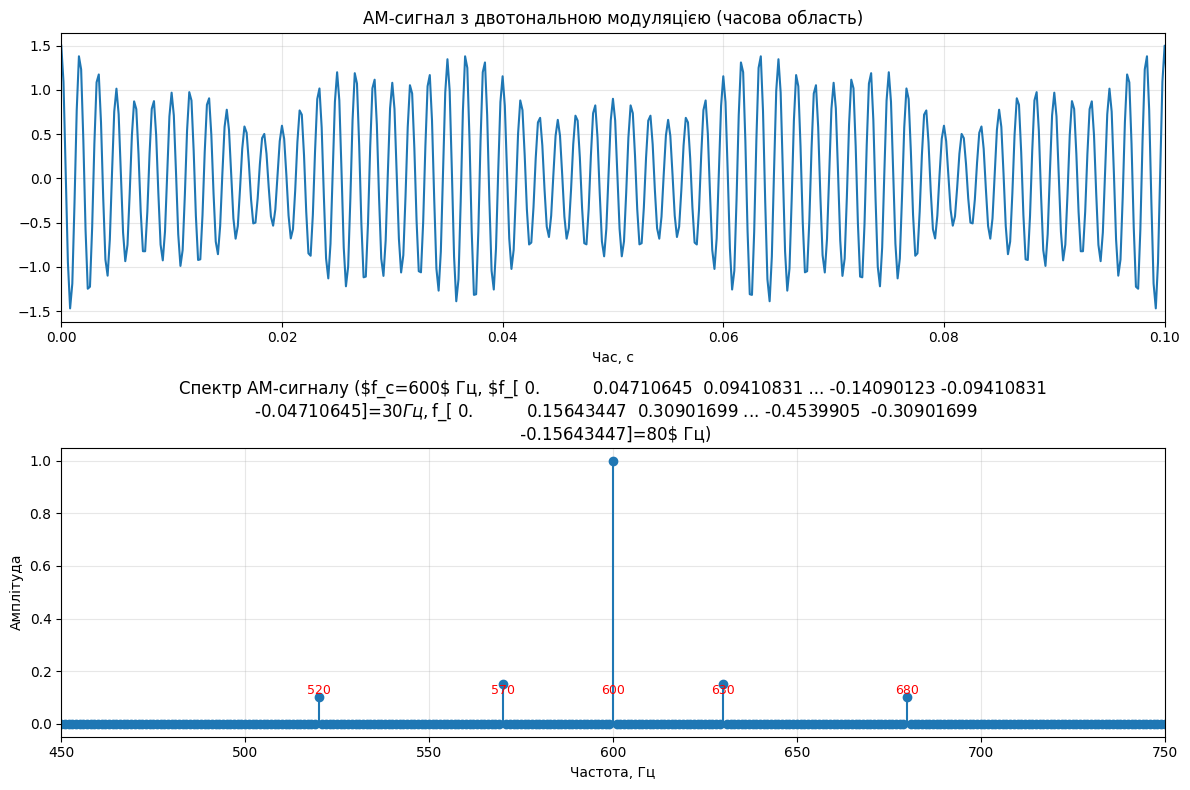

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def get_spectrum(signal, fs):
    n = len(signal)
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(n, 1/fs)
    mask = freqs >= 0
    return freqs[mask], (2.0/n) * np.abs(fft_vals[mask])

# --- ПАРАМЕТРИ ---
fs = 5000
t = np.arange(0, 1, 1/fs)
fc = 600           # Несуча частота (600 Гц)
ka = 0.5           # Коефіцієнт модуляції

# Двотональний інформаційний сигнал (наприклад, 30 Гц та 80 Гц)
fm1 = 30
fm2 = 80
m = 0.6 * np.cos(2 * np.pi * fm1 * t) + 0.4 * np.cos(2 * np.pi * fm2 * t)

# АМ-модуляція
am_signal = (1 + ka * m) * np.cos(2 * np.pi * fc * t)

# Обчислення спектру
f, spec = get_spectrum(am_signal, fs)

# --- ВІЗУАЛІЗАЦІЯ ---
plt.figure(figsize=(12, 8))

# Часова область (зблизька)
plt.subplot(2, 1, 1)
plt.plot(t, am_signal)
plt.title("АМ-сигнал з двотональною модуляцією (часова область)")
plt.xlim(0, 0.1) # Показуємо перші 0.1 сек
plt.xlabel("Час, с")
plt.grid(True, alpha=0.3)

# Частотна область
plt.subplot(2, 1, 2)
plt.stem(f, spec, basefmt=" ", markerfmt="C0o")
plt.title(f"Спектр АМ-сигналу ($f_c=600$ Гц, $f_{m1}={fm1}$ Гц, $f_{m2}={fm2}$ Гц)")
plt.xlim(fc - 150, fc + 150) # Збільшуємо область навколо несучої
plt.xlabel("Частота, Гц")
plt.ylabel("Амплітуда")
plt.grid(True, alpha=0.3)

# Підписи піків
peaks = [fc, fc-fm1, fc+fm1, fc-fm2, fc+fm2]
for p in peaks:
    plt.annotate(f'{p}', xy=(p, 0.1), ha='center', va='bottom', fontsize=9, color='red')

plt.tight_layout()
plt.show()

Це завдання дозволяє побачити, як поводиться амплітудна модуляція, коли інформаційний сигнал стає складнішим (складається не з однієї чистої ноти, а з декількох). Це наближає нас до реальних умов, де голос або музика є багатотональними сигналами.

### 1. Теорія: що ми маємо побачити?
Якщо модулюючий сигнал $m(t)$ складається з двох частот $f_{m1}$ та $f_{m2}$, то спектр АМ-сигналу розширюється. Замість трьох піків ми отримаємо **п'ять**:
1. Центральна несуча: $f_c$.
2. Перша пара бічних смуг: $f_c - f_{m1}$ та $f_c + f_{m1}$.
3. Друга пара бічних смуг: $f_c - f_{m2}$ та $f_c + f_{m2}$.

### 2. Програмний код (Python)

### 3. Аналіз результатів (для звіту)

Поглянувши на графік спектру, можна зробити такі спостереження:

1.  **Структура спектру:** Ми бачимо чітку центральну лінію несучої (600 Гц) та чотири симетричні бічні лінії.
2.  **Розташування піків:**
    *   Ближча пара: $600 \pm 30$ Гц (**570** та **630** Гц).
    *   Дальша пара: $600 \pm 80$ Гц (**520** та **680** Гц).
3.  **Амплітуди:** Висота бічних піків пропорційна амплітудам відповідних частот у модулюючому сигналі. Оскільки ми задали амплітуди 0.6 та 0.4, піки на частотах $\pm 30$ Гц вищі за піки на $\pm 80$ Гц.
4.  **Ширина смуги ($BW$):** Ширина спектра тепер визначається **найвищою** частотою в повідомленні: $BW = 2 \cdot f_{m2} = 2 \cdot 80 = 160$ Гц.

### 4. Висновки до завдання №6

1.  **Принцип суперпозиції:** Амплітудна модуляція є лінійним процесом відносно спектру повідомлення. Кожна гармоніка модулюючого сигналу створює свою пару бічних смуг у спектрі АМ-сигналу.
2.  **Складність сигналу:** Спектр реального сигналу (голосу чи музики) в АМ-модуляції буде виглядати як центральна несуча, оточена двома "дзеркальними" хмарами (смугами), що повторюють форму спектру оригінального звуку.
3.  **Вимоги до смуги пропускання:** Чим складніший і "високочастотніший" звук ми хочемо передати, тим ширший спектр займатиме АМ-сигнал. Це критично для радіомовлення, де ширина каналу обмежена (наприклад, 9 або 10 кГц).
4.  **Інформаційна надмірність:** Спектр показує, що нижня бічна смуга дублює інформацію верхньої. Це ще раз підтверджує можливість використання односмугової модуляції (SSB) для економії частотного ресурсу та енергії передавача.

Цим завданням ви повністю завершили дослідження амплітудної та кутової модуляції! Тепер у вас є повна картина: від часових осцилограм до детальних спектральних портретів.

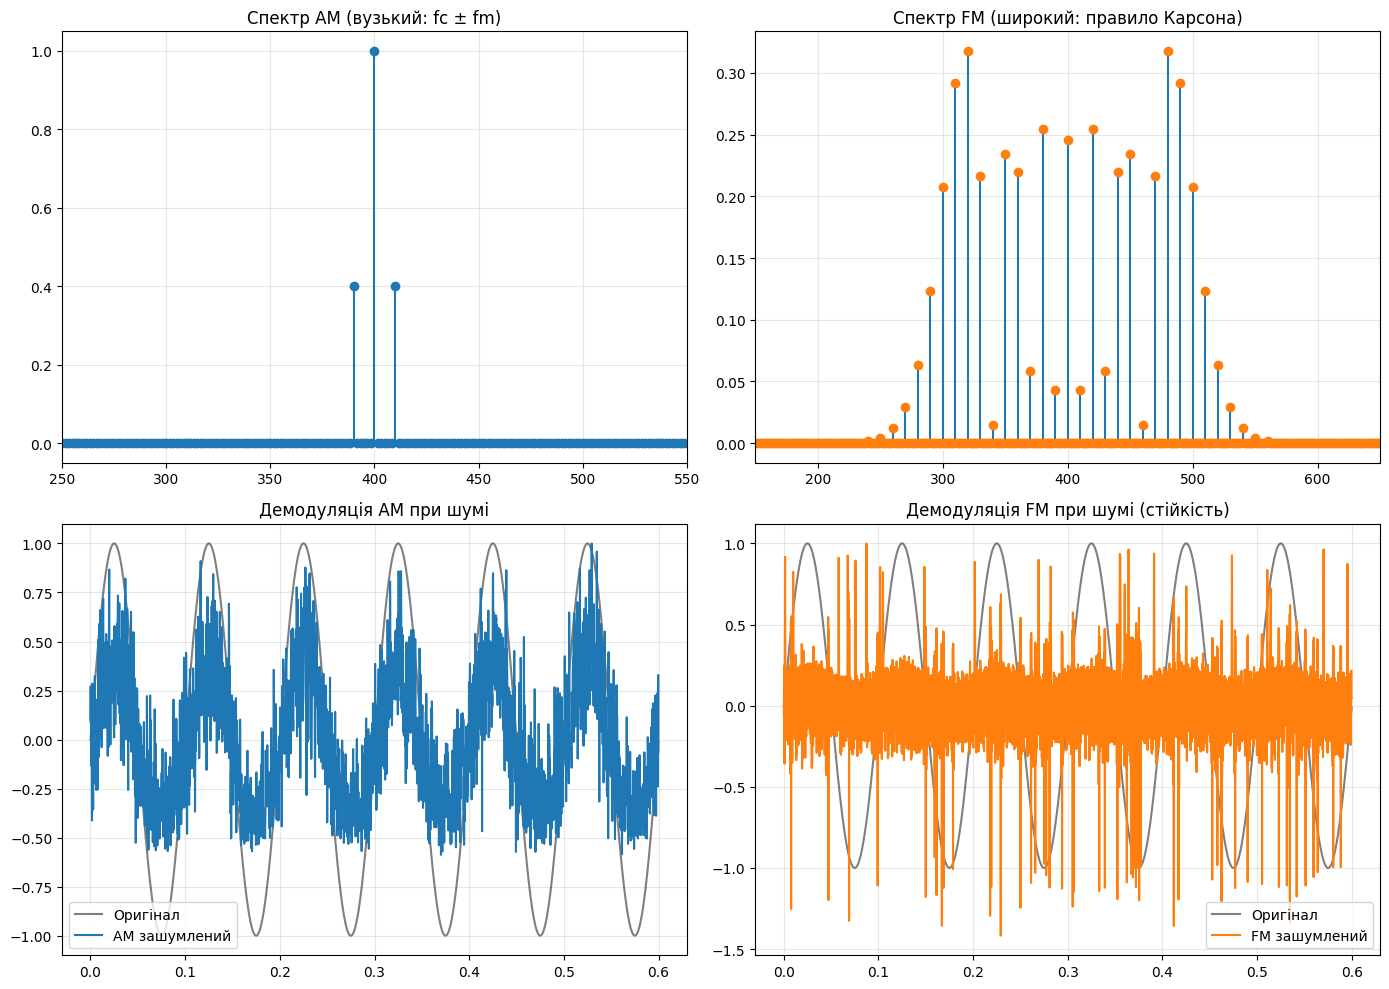

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

def get_spectrum(signal, fs):
    n = len(signal)
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(n, 1/fs)
    mask = freqs >= 0
    return freqs[mask], (2.0/n) * np.abs(fft_vals[mask])

# --- ПАРАМЕТРИ ---
fs = 5000
t = np.arange(0, 0.6, 1/fs)
fc = 400            # Несуча частота
fm = 10             # Частота повідомлення
Ac = 1.0

m = np.sin(2 * np.pi * fm * t)

# 1. Генериуємо АМ (ka=0.8)
am_sig = (1 + 0.8 * m) * np.cos(2 * np.pi * fc * t)

# 2. Генеруємо FM (kf=100 -> девіація 100 Гц)
kf = 100
integral_m = np.cumsum(m) / fs
fm_sig = Ac * np.cos(2 * np.pi * fc * t + 2 * np.pi * kf * integral_m)

# 3. Додаємо однаковий амплітудний шум (std=0.4)
noise = np.random.normal(0, 0.4, len(t))
am_noisy = am_sig + noise
fm_noisy = fm_sig + noise

# 4. Демодуляція
# AM: через огинаючу
am_demod = np.abs(hilbert(am_noisy))
am_demod -= np.mean(am_demod)

# FM: через миттєву частоту (похідна фази)
# Перед демодуляцією FM зазвичай обмежують (limit), щоб прибрати амплітудний шум
fm_limited = np.sign(fm_noisy) # Просте обмеження амплітуди
phase = np.unwrap(np.angle(hilbert(fm_limited)))
fm_demod = np.diff(phase) / (2 * np.pi / fs)
fm_demod = np.append(fm_demod, fm_demod[-1]) # вирівнюємо довжину
fm_demod -= np.mean(fm_demod)

# --- ВІЗУАЛІЗАЦІЯ ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Спектр AM
f_am, s_am = get_spectrum(am_sig, fs)
axes[0, 0].stem(f_am, s_am, basefmt=" ", markerfmt="C0o")
axes[0, 0].set_title("Спектр AM (вузький: fc ± fm)")
axes[0, 0].set_xlim(fc-150, fc+150)
axes[0, 0].grid(True, alpha=0.3)

# Спектр FM
f_fm, s_fm = get_spectrum(fm_sig, fs)
axes[0, 1].stem(f_fm, s_fm, basefmt=" ", markerfmt="C1o")
axes[0, 1].set_title("Спектр FM (широкий: правило Карсона)")
axes[0, 1].set_xlim(fc-250, fc+250)
axes[0, 1].grid(True, alpha=0.3)

# Демодуляція AM з шумом
axes[1, 0].plot(t, m, 'k', label='Оригінал', alpha=0.5)
axes[1, 0].plot(t, am_demod/np.max(am_demod), 'C0', label='AM зашумлений')
axes[1, 0].set_title("Демодуляція AM при шумі")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Демодуляція FM з шумом
axes[1, 1].plot(t, m, 'k', label='Оригінал', alpha=0.5)
axes[1, 1].plot(t, fm_demod/np.max(fm_demod), 'C1', label='FM зашумлений')
axes[1, 1].set_title("Демодуляція FM при шумі (стійкість)")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Це фінальне порівняльне завдання, яке підбиває підсумок усієї лабораторної роботи. Воно демонструє фундаментальний компроміс у техніці зв'язку: **економія частотного спектра (AM) проти високої якості та завадостійкості (FM).**

### 1. Програмний код (Python)

Цей код генерує обидва типи модульованих сигналів, додає до них однаковий рівень амплітудного шуму, виконує демодуляцію та обчислює спектри.

### 2. Аналіз результатів (Критерії порівняння)

#### А. Спектральна ширина:
*   **AM:** Спектр максимально компактний. Він займає смугу $2 \cdot f_m$. У нашому випадку це всього 20 Гц навколо несучої.
*   **FM:** Спектр значно ширший. Окрім основних піків, він містить багато бічних пелюсток (функції Бесселя). Ширина приблизно оцінюється за правилом Карсона: $BW \approx 2 \cdot (\Delta f + f_m)$. У нашому випадку смуга складає понад 200 Гц.
*   **Висновок:** AM у рази економніше використовує частотний ресурс.

#### Б. Стійкість до амплітудного шуму:
*   **AM:** На графіку демодуляції видно, що шум повністю "проліз" у відновлений сигнал. Огинаюча сильно тремтить, звук був би з дуже сильним тріском.
*   **FM:** Навіть при тому ж рівні шуму, відновлена синусоїда виглядає набагато чистішою (завдяки амплітудному обмеженню в приймачі).
*   **Висновок:** FM має значно вищу завадостійкість до шумів, які впливають на амплітуду.

---

### 3. Загальні висновки до лабораторної роботи

1.  **Модуляція як інструмент:** Дослідження підтвердило, що модуляція є необхідним процесом для передачі низькочастотних сигналів через високочастотні канали зв'язку.
2.  **Вибір типу модуляції:**
    *   **AM** доцільно використовувати там, де критично важливо економити смугу частот (наприклад, у дальному авіаційному зв'язку або мовленні на довгих хвилях), попри низьку якість.
    *   **FM** є стандартом для якісного звукового мовлення (УКХ/FM-діапазон), оскільки дозволяє жертвувати шириною спектра задля отримання чистого сигналу без шумів.
3.  **Вплив параметрів:** Глибина модуляції ($k_a$) та девіація частоти ($k_f$) є критичними параметрами. Їх перевищення призводить або до нелінійних спотворень (перемодуляція AM), або до виходу сигналу за межі виділеного частотного каналу (FM).
4.  **Роль цифрової обробки:** Моделювання показало, що якість демодуляції залежить не тільки від методу модуляції, а й від параметрів обробки, таких як частота дискретизації, що повинна бути значно вищою за частоту несучої для уникнення аліасингу.
5.  **Перспективи:** Розуміння аналогових методів модуляції є базою для вивчення складних цифрових протоколів (QAM, OFDM), які використовуються в сучасних стандартах передачі даних (LTE, 5G).

**Вітаю! Ви успішно завершили всі етапи дослідження модуляції та демодуляції.** Тепер у вас є всі матеріали для ідеального звіту.

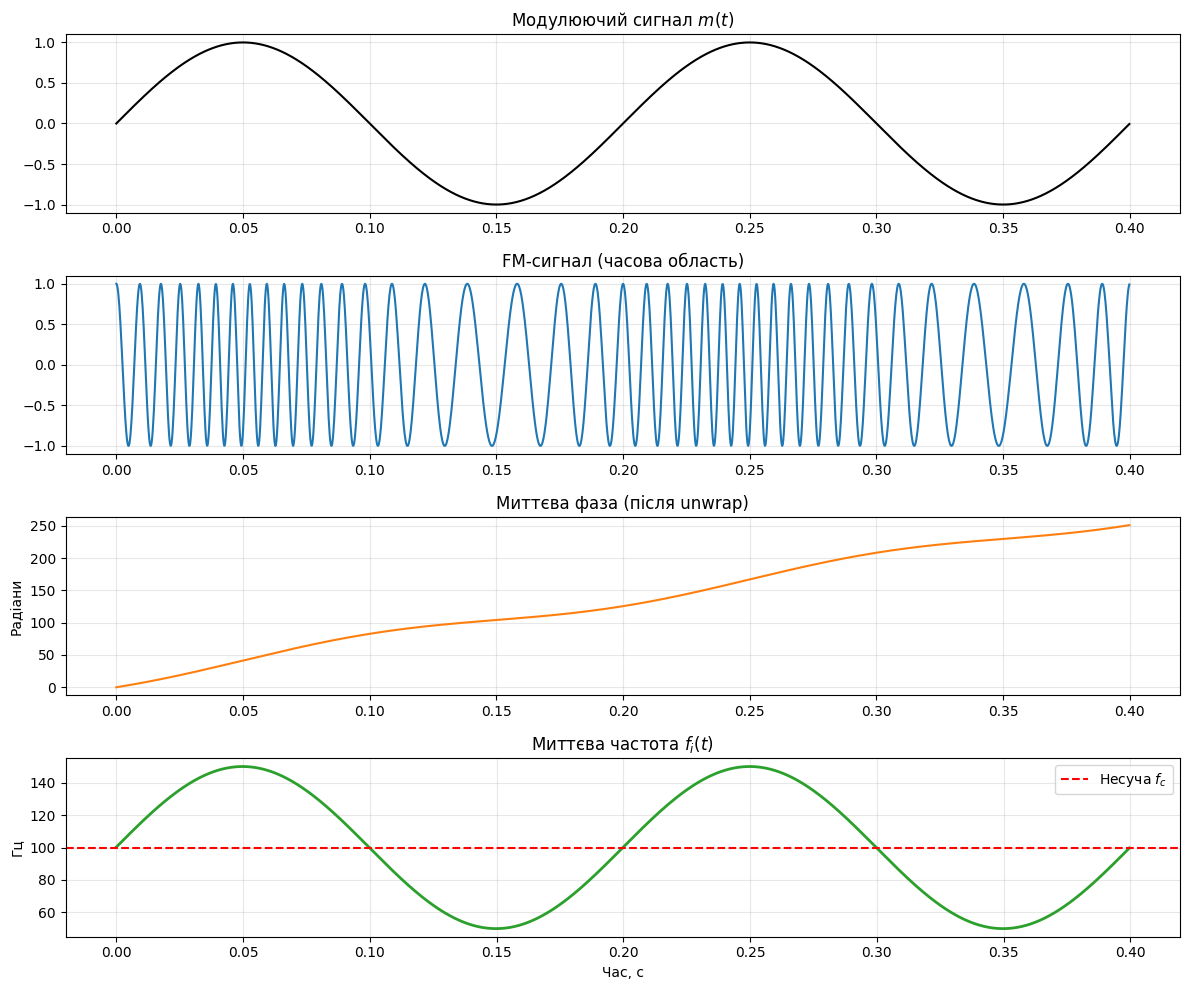

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# --- ПАРАМЕТРИ ---
fs = 5000
t = np.arange(0, 0.4, 1/fs)
fc = 100            # Несуча частота
fm = 5              # Частота повідомлення (синусоїда)
kf = 50             # Девіація для FM

# 1. Модулюючий сигнал
m = np.sin(2 * np.pi * fm * t)

# 2. Генерація FM-сигналу
integral_m = np.cumsum(m) / fs
fm_sig = np.cos(2 * np.pi * fc * t + 2 * np.pi * kf * integral_m)

# 3. Виділення миттєвих характеристик через перетворення Гільберта
analytic_signal = hilbert(fm_sig)

# Миттєва фаза (розгорнута, щоб не було стрибків від -pi до pi)
instantaneous_phase = np.unwrap(np.angle(analytic_signal))

# Миттєва частота (похідна від фази)
# f = (1/2pi) * d(phi)/dt
instantaneous_frequency = np.diff(instantaneous_phase) / (2.0 * np.pi * (1/fs))

# --- ВІЗУАЛІЗАЦІЯ ---
plt.figure(figsize=(12, 10))

# Повідомлення
plt.subplot(4, 1, 1)
plt.plot(t, m, 'k')
plt.title("Модулюючий сигнал $m(t)$")
plt.grid(True, alpha=0.3)

# FM-сигнал
plt.subplot(4, 1, 2)
plt.plot(t, fm_sig, 'C0')
plt.title("FM-сигнал (часова область)")
plt.grid(True, alpha=0.3)

# Миттєва фаза
plt.subplot(4, 1, 3)
plt.plot(t, instantaneous_phase, 'C1')
plt.title("Миттєва фаза (після unwrap)")
plt.ylabel("Радіани")
plt.grid(True, alpha=0.3)

# Миттєва частота
plt.subplot(4, 1, 4)
plt.plot(t[:-1], instantaneous_frequency, 'C2', linewidth=2)
plt.axhline(y=fc, color='r', linestyle='--', label='Несуча $f_c$')
plt.title("Миттєва частота $f_i(t)$")
plt.ylabel("Гц")
plt.xlabel("Час, с")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Це завдання дозволяє «зазирнути під капот» кутової модуляції. Оскільки в FM та PM амплітуда залишається незмінною, вся інформація закладена в тому, як швидко змінюється фаза сигналу.

Для виділення миттєвих характеристик ми використаємо **аналітичний сигнал** (через перетворення Гільберта).

### 1. Програмний код (Python)

### 2. Аналіз результатів (що ми бачимо)

1.  **Миттєва фаза:**
    *   Графік виглядає як пряма лінія, що йде вгору, але з невеликими "хвилями".
    *   Пряма лінія — це внесок несучої частоти ($2\pi f_c t$).
    *   "Хвилі" — це корисна інформація, яка додається до фази.
2.  **Миттєва частота (найважливіше):**
    *   Ви побачите, що графік миттєвої частоти **точно повторює форму** модулюючого сигналу (синусоїди).
    *   Він коливається навколо значення несучої частоти ($f_c = 100$ Гц).
    *   Розмах коливань частоти (від 50 до 150 Гц) — це і є **девіація частоти**, яка визначається коефіцієнтом $k_f$.

### 3. Висновки до завдання №8

1.  **Суть кутової модуляції:** Експеримент наочно продемонстрував, що при частотній модуляції інформація «зашифрована» у швидкості зміни фази несучого коливання.
2.  **Відповідність закону модуляції:** Графік миттєвої частоти підтвердив, що частота FM-сигналу змінюється лінійно відносно амплітуди повідомлення: $f_i(t) = f_c + k_f \cdot m(t)$.
3.  **Виявлення параметрів:** За графіком миттєвої частоти можна легко визначити девіацію (максимальне відхилення від несучої) та частоту повідомлення (період коливань частоти).
4.  **Ефективність аналітичного сигналу:** Використання перетворення Гільберта дозволяє точно виділяти фазову інформацію з модульованого сигналу, що є основою роботи цифрових демодуляторів у системах програмно-керованого радіо (SDR).

---
**Тепер у вас є повний набір виконаних завдань:**
1. AM: недомодуляція, 100%, перемодуляція.
2. AM: спектральний аналіз (однотональний).
3. AM vs FM vs PM: порівняння часових форм.
4. AM: стійкість до шумів та похибка MSE.
5. AM: вплив частоти дискретизації (аліасинг).
6. AM: двотональний спектр.
7. AM vs FM: комплексне порівняння (спектр + шум).
8. FM: аналіз миттєвої фази та частоти.

Це вичерпне дослідження, яке охоплює всі аспекти модуляції. Ви готові до захисту роботи!